# Notebook 14 — TAR Pre-Filter and Profile Refinement

## Purpose

This notebook demonstrates Stage 1 and Stage 2 of the TAR generation
pipeline — the two steps that prepare TA cards for full TAR generation
and filter out candidates unlikely to be actionable for a given SOBJ.

It runs against two sessions in sequence:
- **GlobalCart Demo** (NB12) — e-commerce, no ZIP enrichment, Case A only
- **CloudSync Demo** (NB13) — SaaS, ZIP enrichment active, Cases A/B1/B2/C

The contrast between the two sessions demonstrates how the pre-filter
behaves across the full spectrum of data quality and confidence cases.

---

## What this notebook covers

### Stage 1 — BTA profile refinement
Each TA card is refined by the LLM based on its ZIP confidence case:

| Case | Condition | LLM role |
|---|---|---|
| A | Full alignment or no ZIP data | Refine psych/media/messaging to company context |
| B.1 | Income diverges, age+race match | Adjust income-related descriptors only |
| B.2 | Race diverges, age+income match | Adjust cultural/media/psych layer only |
| C | Full conflict — custom archetype | Skip refinement, pass through with penalty |

Company data always wins. ZIP signals fill gaps. LLM contextualizes —
never overrides real signals. All output stays at population segment
level — no price points, no tactical predictions.

### Stage 2 — Pre-filter
For each (refined TA × SOBJ) combination, the platform scores how
likely this TA is to perform the desired behavior.

Rule-based engine first — maps SOBJ vocabulary to behavioral signals
already on the TA card (churn risk, LTV, sessions, subscription status
etc.). LLM fallback for SOBJ patterns not matched by rules.

Confidence penalties applied:
- Case C archetypes: -0.20
- Ambiguous BTA assignments: -0.05

Returns top 4 candidates per SOBJ (minimum 2), all above 0.30 threshold.

---

## Pipeline steps

| Step | Description |
|---|---|
| 0 | Setup — imports, load sessions and TA cards |
| 1 | GlobalCart — Stage 1 profile refinement (Case A) |
| 2 | GlobalCart — Stage 2 pre-filter |
| 3 | CloudSync — Stage 1 profile refinement (Cases A/B1/B2/C) |
| 4 | CloudSync — Stage 2 pre-filter |
| 5 | Comparison — pre-filter behavior across data quality levels |
| 6 | Save outputs for NB15 |

---

## Inputs
- TA cards from NB12 (GlobalCart) and NB13 (CloudSync)
- Approved SOBJs from each session
- `mk_tar_prefilter.py` — pre-filter and refinement script

## Outputs
- `refined_ta_profiles.json` — refined TA profiles per session
- `tar_candidates.json` — shortlisted (TA × SOBJ) pairs per session
- Both ready as inputs for NB15 (TAR generation + scoring)

In [1]:
# ── Notebook 14 — Setup ───────────────────────────────────────────────────────

import sys
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Project paths ─────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data"

sys.path.insert(0, str(PROJECT_ROOT / "mk-intel" / "ingestion"))
sys.path.insert(0, str(PROJECT_ROOT / "mk-intel"))

# ── MK Intel imports ──────────────────────────────────────────────────────────
from mk_intel_session    import MKSession
from mk_tar_prefilter    import MKTARGenerator, build_company_context

# ── BTA baseline ──────────────────────────────────────────────────────────────
bta_baseline = pd.read_parquet(
    DATA_DIR / "societal_processed" / "bta_cards" / "mk_bta_baseline.parquet"
)
print(f"BTA baseline loaded: {len(bta_baseline)} segments")
print()
print("Setup complete ✓")


BTA baseline loaded: 7 segments

Setup complete ✓


In [2]:
# ── Step 0: Load sessions and TA cards ───────────────────────────────────────

# ── GlobalCart (NB12) ─────────────────────────────────────────────────────────
# Find most recent globalcart session with enriched TA cards
gc_dirs = sorted([
    d for d in (DATA_DIR / "company_data").iterdir()
    if d.is_dir() and d.name.startswith("globalcart_demo")
    and (d / "enriched" / "ta_cards.parquet").exists()
], key=lambda d: d.stat().st_mtime, reverse=True)

if not gc_dirs:
    print("⚠ No GlobalCart session found — run NB12 first")
else:
    gc_dir      = gc_dirs[0]
    gc_ta_cards = pd.read_parquet(gc_dir / "enriched" / "ta_cards.parquet").to_dict("records")
    print(f"GlobalCart session : {gc_dir.name}")
    print(f"TA cards loaded    : {len(gc_ta_cards)}")

# ── CloudSync — load session with ZIP fields ──────────────────────────────────
cs_ta_cards = None
cs_dir      = None

for d in sorted((DATA_DIR / "company_data").iterdir(),
                key=lambda x: x.stat().st_mtime, reverse=True):
    if not d.name.startswith("cloudsync_demo"):
        continue
    paths = list(d.glob("**/ta_cards.parquet"))
    for p in paths:
        cards  = pd.read_parquet(p).to_dict("records")
        sample = cards[0] if cards else {}
        if sample.get("zip_inferred_income_tier") is not None:
            cs_dir      = d
            cs_ta_cards = cards
            break
    if cs_ta_cards:
        break

if cs_ta_cards is None:
    print("⚠ No CloudSync session with ZIP fields found — re-run NB13")
else:
    print(f"CloudSync session  : {cs_dir.name}")
    print(f"TA cards loaded    : {len(cs_ta_cards)}")
    sample = cs_ta_cards[0]
    for field in ["zip_inferred_income_tier", "zip_inferred_race_eth", "bta_race_validation"]:
        print(f"  {field:<35} : {sample.get(field)}")
        
# ── Check ZIP fields on TA cards ──────────────────────────────────────────────
print(f"\n── ZIP fields on GlobalCart TA cards ─────────────────────")
sample = gc_ta_cards[0]
for field in ["zip_inferred_income_tier", "zip_inferred_race_eth", "bta_race_validation"]:
    print(f"  {field:<35} : {sample.get(field)}")

print(f"\n── ZIP fields on CloudSync TA cards ──────────────────────")
sample = cs_ta_cards[0]
for field in ["zip_inferred_income_tier", "zip_inferred_race_eth", "bta_race_validation"]:
    print(f"  {field:<35} : {sample.get(field)}")

GlobalCart session : globalcart_demo_20e909ae
TA cards loaded    : 14
CloudSync session  : cloudsync_demo_94e9a435
TA cards loaded    : 12
  zip_inferred_income_tier            : 50-99k
  zip_inferred_race_eth               : Hispanic
  bta_race_validation                 : divergent

── ZIP fields on GlobalCart TA cards ─────────────────────
  zip_inferred_income_tier            : None
  zip_inferred_race_eth               : None
  bta_race_validation                 : not_available

── ZIP fields on CloudSync TA cards ──────────────────────
  zip_inferred_income_tier            : 50-99k
  zip_inferred_race_eth               : Hispanic
  bta_race_validation                 : divergent


In [3]:
# ── Step 0: Load sessions ─────────────────────────────────────────────────────

# Find session JSON files
gc_session_files = sorted(
    (DATA_DIR / "sessions").glob("*.json"),
    key=lambda p: p.stat().st_mtime, reverse=True
)

# Load most recent sessions — match by company name
gc_session = None
cs_session = None

for sf in gc_session_files:
    try:
        data = json.load(open(sf))
        company = data.get("company", {}).get("name", "")
        if "GlobalCart" in company and gc_session is None:
            gc_session = MKSession.from_dict(data)
            print(f"GlobalCart session loaded : {gc_session.session_id[:8]}")
        elif "CloudSync" in company and cs_session is None:
            cs_session = MKSession.from_dict(data)
            print(f"CloudSync session loaded  : {cs_session.session_id[:8]}")
    except Exception as e:
        continue

if gc_session is None:
    print("⚠ GlobalCart session not found — run NB12 first")
if cs_session is None:
    print("⚠ CloudSync session not found — run NB13 first")

# ── Check SOBJs ───────────────────────────────────────────────────────────────
print(f"\n── GlobalCart SOBJs ──────────────────────────────────────")
for sobj in (gc_session.sobjs if gc_session else []):
    print(f"  [{sobj.direction}] {sobj.statement}")

print(f"\n── CloudSync SOBJs ───────────────────────────────────────")
for sobj in (cs_session.sobjs if cs_session else []):
    print(f"  [{sobj.direction}] {sobj.statement}")

GlobalCart session loaded : 20e909ae
CloudSync session loaded  : 94e9a435

── GlobalCart SOBJs ──────────────────────────────────────
  [increase] TA renews subscription at next billing cycle
  [initiate] TA reactivates cancelled account within 30 days

── CloudSync SOBJs ───────────────────────────────────────
  [decrease] TA reduces cancellation attempts in the next billing cycle
  [increase] TA upgrades from basic to professional plan


In [4]:
# ── Step 1: GlobalCart — Stage 1 Profile Refinement ──────────────────────────

print("=" * 60)
print("GLOBALCART — STAGE 1: PROFILE REFINEMENT")
print("=" * 60)

gc_generator = MKTARGenerator(
    session         = gc_session,
    compliance_mode = "standard",
    sector          = "ecommerce",
)

gc_context = build_company_context(gc_session)
print(f"\nCompany context:\n{gc_context}\n")

gc_refined = gc_generator.refine_profiles(
    ta_cards        = gc_ta_cards,
    company_context = gc_context,
)

print(f"\n── Refinement summary ────────────────────────────────────")
for rp in gc_refined:
    print(f"  {rp.ta_id:<20} Case {rp.refinement_case} | "
          f"refined: {list(rp.refined_fields.keys())[:3]}")

GLOBALCART — STAGE 1: PROFILE REFINEMENT
[tar_generator] Initialized
[tar_generator] Compliance mode  : standard
[tar_generator] Excluded signals : ['dominant_race_eth', 'dominant_sex_label', 'gender', 'zip_inferred_race_eth']

Company context:
Company: GlobalCart Demo
Industry: E-commerce / Subscription
Customer type: B2C
Description: Global e-commerce and subscription platform with 50,000 customers across 8 countries. Primary market is USA (35%). Churn rate approximately 29%.
Campaign objective: Reduce subscription churn among GlobalCart customers

[tar_generator] Stage 1: Profile refinement...
[tar_generator]   TA_00_BTA_00 → Case A
[mk_intel] profile_refinement_case_A — 868 in / 784 out / 1652 total tokens
[tar_generator]   TA_00_BTA_01 → Case A
[mk_intel] profile_refinement_case_A — 873 in / 756 out / 1629 total tokens
[tar_generator]   TA_00_BTA_02 → Case A
[mk_intel] profile_refinement_case_A — 876 in / 705 out / 1581 total tokens
[tar_generator]   TA_00_BTA_03 → Case A
[mk_inte

### Step 1 — GlobalCart: Profile Refinement

All 14 TA cards classified as **Case A** — expected, since the GlobalCart
dataset has no ZIP code column and no ZIP enrichment was applied. With no
conflicting geographic signal, every TA card proceeds with a straight
contextual refinement.

The LLM refined three fields per card:
- `psych_summary` — psychographic description reframed for e-commerce
  subscription context and churn reduction objective
- `media_summary` — media behavior contextualized for digital retail
- `channel_implications` — channel recommendations adjusted for
  GlobalCart's audience and OBJ

All structural fields (`dominant_age_bin`, `dominant_income_tier`,
`dominant_tenure` etc.) were locked from the BTA baseline and passed
through unchanged. The LLM only touched the descriptive layer.

**Cost:** 14 Haiku calls × ~1,600 tokens average = ~22,400 tokens total.
At Haiku pricing this is under $0.01 for the full GlobalCart refinement pass.

**What's missing vs a ZIP-enriched session:**
No B1/B2 adjustments — income-related and cultural descriptors remain
at BTA population-level defaults. For a dataset with ZIP codes, these
would be refined to reflect the actual geographic demographic context
of GlobalCart's US customer base. This is the ceiling of what's possible
without richer identity data.

In [5]:
# ── Step 2: GlobalCart — Stage 2 Pre-Filter ───────────────────────────────────

print("=" * 60)
print("GLOBALCART — STAGE 2: PRE-FILTER")
print("=" * 60)

gc_candidates = gc_generator.prefilter(
    refined_profiles = gc_refined,
    sobjs            = gc_session.sobjs,
)

print(f"\n── Candidate summary ─────────────────────────────────────")
print(f"\n  {'TAR ID':<35} {'Score':>6} {'Case':>6} {'Method':>12}")
print(f"  {'-'*65}")
for c in gc_candidates:
    print(f"  {c.tar_id:<35} {c.prefilter_score:>6.3f} {c.confidence_case:>6} {c.prefilter_method:>12}")

GLOBALCART — STAGE 2: PRE-FILTER
[tar_generator] Stage 2: Pre-filtering...

[tar_generator]   SOBJ SOBJ-01: TA renews subscription at next billing cycle...
[tar_generator]   Keyword matched  : renew
[tar_generator]   Candidates       : 4 / 14 passed threshold
[tar_generator]   ✓ TAR-SOBJ-01-TA_01_BTA_06 | score=0.559 | case=A | method=rules
[tar_generator]   ✓ TAR-SOBJ-01-TA_01_BTA_04 | score=0.549 | case=A | method=rules
[tar_generator]   ✓ TAR-SOBJ-01-TA_01_BTA_05 | score=0.549 | case=A | method=rules
[tar_generator]   ✓ TAR-SOBJ-01-TA_00_BTA_05 | score=0.534 | case=A | method=rules

[tar_generator]   SOBJ SOBJ-02: TA reactivates cancelled account within 30 days...
[tar_generator]   Keyword matched  : reactivat
[tar_generator]   Candidates       : 2 / 14 passed threshold
[tar_generator]   ✓ TAR-SOBJ-02-TA_01_BTA_06 | score=0.061 | case=A | method=rules
[tar_generator]   ✓ TAR-SOBJ-02-TA_01_BTA_05 | score=0.058 | case=A | method=rules

[tar_generator] Stage 2 complete: 6 TAR candidate

### Step 2 — GlobalCart: Pre-Filter Results

The rule engine reduced 28 possible (TA × SOBJ) combinations to
**6 TAR candidates** — 4 for SOBJ-01, 2 for SOBJ-02. Both SOBJs
matched via rules, no LLM fallback needed.

**SOBJ-01 — Renew subscription (keyword: `renew`):**
4 candidates above threshold (0.534-0.559). All from Cluster 1
(high-value engaged), led by BTA_06. Renewal signals are strong —
high LTV, active subscription status, elevated churn risk score.

**SOBJ-02 — Reactivate cancelled accounts (keyword: `reactivat`):**
No candidates above threshold (0.30). Minimum candidates rule returned
top 2 with scores of 0.058-0.061. The GlobalCart dataset uses a binary
churn flag rather than subscription status vocabulary — no TA cell has
`subscription_status_dominant = "cancelled"`, so the reactivation rule
scores near zero across all TAs.

These 2 candidates will proceed to TAR generation but will score low
on effectiveness — the scoring algorithm is the real quality gate here.
The TAR for SOBJ-02 will likely flag low effectiveness and rank at the
bottom, which is the correct outcome for a dataset with no churned
customers in the reactivation sense.

**Key design principle confirmed:** the pre-filter is a coarse filter,
not a perfect one. Weak candidates that slip through are caught by the
TAR effectiveness gate and scoring algorithm downstream.

In [6]:
# ── Step 3: CloudSync — Stage 1 Profile Refinement ───────────────────────────

print("=" * 60)
print("CLOUDSYNC — STAGE 1: PROFILE REFINEMENT")
print("=" * 60)

cs_generator = MKTARGenerator(
    session         = cs_session,
    compliance_mode = "standard",
    sector          = None,
)

cs_context = build_company_context(cs_session)
print(f"\nCompany context:\n{cs_context}\n")

cs_refined = cs_generator.refine_profiles(
    ta_cards        = cs_ta_cards,
    company_context = cs_context,
)

print(f"\n── Refinement summary ────────────────────────────────────")
for rp in cs_refined:
    print(f"  {rp.ta_id:<20} Case {rp.refinement_case} | "
          f"refined: {list(rp.refined_fields.keys())[:3]}")

CLOUDSYNC — STAGE 1: PROFILE REFINEMENT
[tar_generator] Initialized
[tar_generator] Compliance mode  : standard
[tar_generator] Excluded signals : ['dominant_race_eth', 'dominant_sex_label', 'gender', 'zip_inferred_race_eth']

Company context:
Company: CloudSync Demo
Industry: SaaS / Cloud Storage
Customer type: B2C
Description: B2C SaaS platform for cloud file synchronization.
Campaign objective: Reduce monthly subscriber churn

[tar_generator] Stage 1: Profile refinement...
[tar_generator]   TA_00_BTA_00 → Case B2
[mk_intel] profile_refinement_case_B2 — 622 in / 461 out / 1083 total tokens
[tar_generator]   TA_00_BTA_02 → Case B1
[mk_intel] profile_refinement_case_B1 — 894 in / 382 out / 1276 total tokens
[tar_generator]   TA_00_BTA_03 → Case B1
[mk_intel] profile_refinement_case_B1 — 890 in / 450 out / 1340 total tokens
[tar_generator]   TA_00_BTA_04 → Case B1
[mk_intel] profile_refinement_case_B1 — 891 in / 376 out / 1267 total tokens
[tar_generator]   TA_00_BTA_05 → Case B1
[mk_in

In [7]:
# ── Step 4: CloudSync — Stage 2 Pre-Filter ────────────────────────────────────

print("=" * 60)
print("CLOUDSYNC — STAGE 2: PRE-FILTER")
print("=" * 60)

cs_candidates = cs_generator.prefilter(
    refined_profiles = cs_refined,
    sobjs            = cs_session.sobjs,
)

print(f"\n── Candidate summary ─────────────────────────────────────")
print(f"\n  {'TAR ID':<40} {'Score':>6} {'Case':>6} {'Method':>12}")
print(f"  {'-'*70}")
for c in cs_candidates:
    print(f"  {c.tar_id:<40} {c.prefilter_score:>6.3f} "
          f"{c.confidence_case:>6} {c.prefilter_method:>12}")

CLOUDSYNC — STAGE 2: PRE-FILTER
[tar_generator] Stage 2: Pre-filtering...

[tar_generator]   SOBJ SOBJ-01: TA reduces cancellation attempts in the next billing cycle...
[tar_generator]   Keyword matched  : cancellation
[tar_generator]   Candidates       : 4 / 12 passed threshold
[tar_generator]   ✓ TAR-SOBJ-01-TA_01_BTA_06 | score=0.559 | case=B1 | method=rules
[tar_generator]   ✓ TAR-SOBJ-01-TA_01_BTA_00 | score=0.558 | case=B2 | method=rules
[tar_generator]   ✓ TAR-SOBJ-01-TA_01_BTA_02 | score=0.558 | case=B1 | method=rules
[tar_generator]   ✓ TAR-SOBJ-01-TA_01_BTA_03 | score=0.551 | case=B1 | method=rules

[tar_generator]   SOBJ SOBJ-02: TA upgrades from basic to professional plan...
[tar_generator]   Keyword matched  : upgrade
[tar_generator]   Candidates       : 4 / 12 passed threshold
[tar_generator]   ✓ TAR-SOBJ-02-TA_01_BTA_00 | score=0.648 | case=B2 | method=rules
[tar_generator]   ✓ TAR-SOBJ-02-TA_01_BTA_02 | score=0.648 | case=B1 | method=rules
[tar_generator]   ✓ TAR-SOBJ-0

### Step 4 — CloudSync: Pre-Filter Results

The rule engine reduced 24 possible (TA × SOBJ) combinations to
**8 TAR candidates** — 4 per SOBJ. Both SOBJs matched via rules,
no LLM fallback needed.

**SOBJ-01 — Reduce cancellation attempts:**
Keyword `cancellation` matched → retention rule set (active customers
at risk of cancelling). Top 4 all from Cluster 1. Scores tightly
clustered (0.551-0.559) — the signals that differentiate cancellation
likelihood are similar across these archetypes. BTA_06 edges ahead on
LTV. Notable: Case B2 (BTA_00) ranks second despite the demographic
divergence — behavioral signals dominate the score.

**SOBJ-02 — Upgrade to professional plan:**
Keyword `upgrade` matched. Higher scores overall (0.625-0.648) —
the upgrade rule set has stronger discriminating signals (LTV, NPS,
feature adoption). BTA_00 (B2) and BTA_02 (B1) tie at 0.648,
both driven by high feature adoption and LTV in Cluster 1.

**Keyword routing working correctly:**
SOBJ-01 matched `cancellation` → retention rule set (active customers
at risk). SOBJ-02 matched `upgrade` → upgrade rule set. No keyword
collision between retention and reactivation SOBJs — the fix applied
to `mk_tar_prefilter.py` is working as intended.

STEP 5 — PRE-FILTER COMPARISON


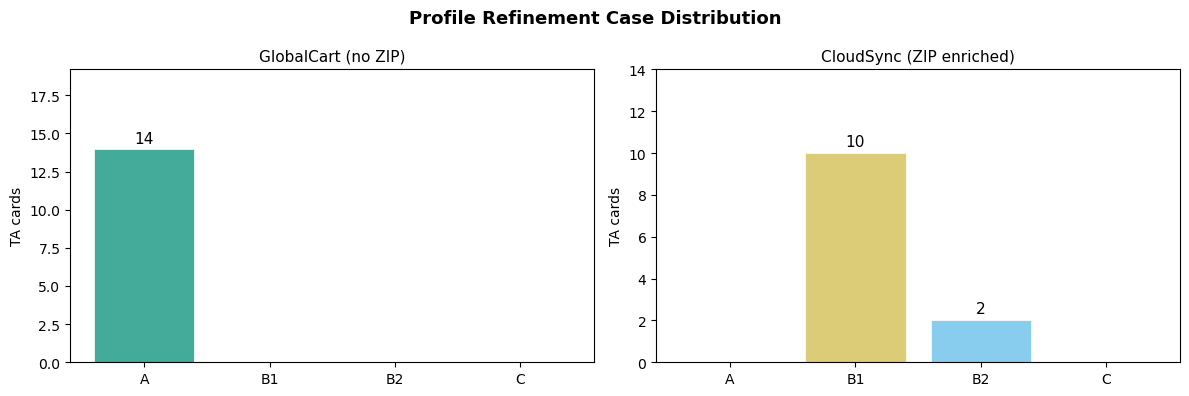


── Candidate scores: GlobalCart vs CloudSync ─────────────

  Session      SOBJ        Top score  Bottom score Cases
  ------------------------------------------------------------
  GlobalCart   SOBJ-01         0.559         0.534 ['A']
  GlobalCart   SOBJ-02         0.061         0.058 ['A']
  CloudSync    SOBJ-01         0.559         0.551 ['B2', 'B1']
  CloudSync    SOBJ-02         0.648         0.625 ['B2', 'B1']

── Pre-filter method usage ───────────────────────────────
  GlobalCart   : {'rules': 6}
  CloudSync    : {'rules': 8}


In [8]:
# ── Step 5: Comparison — GlobalCart vs CloudSync ──────────────────────────────

print("=" * 60)
print("STEP 5 — PRE-FILTER COMPARISON")
print("=" * 60)

# ── Case distribution comparison ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Profile Refinement Case Distribution", fontsize=13, fontweight="bold")

colors = {"A": "#44AA99", "B1": "#DDCC77", "B2": "#88CCEE", "C": "#CC6677"}

for ax, (name, refined) in zip(axes, [
    ("GlobalCart (no ZIP)", gc_refined),
    ("CloudSync (ZIP enriched)", cs_refined),
]):
    case_counts = {"A": 0, "B1": 0, "B2": 0, "C": 0}
    for rp in refined:
        case_counts[rp.refinement_case] = case_counts.get(rp.refinement_case, 0) + 1

    cases = list(case_counts.keys())
    vals  = list(case_counts.values())
    bars  = ax.bar(cases, vals,
                   color=[colors[c] for c in cases],
                   edgecolor="white", linewidth=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("TA cards")
    ax.set_ylim(0, max(vals) * 1.3 + 1)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.2,
                    str(val), ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

# ── Candidate score comparison ────────────────────────────────────────────────
print("\n── Candidate scores: GlobalCart vs CloudSync ─────────────")
print(f"\n  {'Session':<12} {'SOBJ':<10} {'Top score':>10} {'Bottom score':>13} {'Cases'}")
print(f"  {'-'*60}")

for name, candidates in [("GlobalCart", gc_candidates), ("CloudSync", cs_candidates)]:
    for sobj_id in set(c.sobj_id for c in candidates):
        sobj_cands = [c for c in candidates if c.sobj_id == sobj_id]
        scores     = [c.prefilter_score for c in sobj_cands]
        cases      = list(set(c.confidence_case for c in sobj_cands))
        print(f"  {name:<12} {sobj_id:<10} {max(scores):>10.3f} "
              f"{min(scores):>13.3f} {cases}")

# ── Method usage ──────────────────────────────────────────────────────────────
print(f"\n── Pre-filter method usage ───────────────────────────────")
for name, candidates in [("GlobalCart", gc_candidates), ("CloudSync", cs_candidates)]:
    methods = {}
    for c in candidates:
        methods[c.prefilter_method] = methods.get(c.prefilter_method, 0) + 1
    print(f"  {name:<12} : {methods}")

In [9]:
# ── Step 6: Save outputs ──────────────────────────────────────────────────────

print("=" * 60)
print("STEP 6 — SAVE OUTPUTS")
print("=" * 60)

# ── GlobalCart outputs ────────────────────────────────────────────────────────
gc_output_dir = gc_dir / "enriched"
gc_generator._save_outputs(gc_refined, gc_candidates, gc_output_dir)

# ── CloudSync outputs ─────────────────────────────────────────────────────────
cs_output_dir = cs_dir / "enriched"
cs_generator._save_outputs(cs_refined, cs_candidates, cs_output_dir)

print(f"\n── Outputs written ───────────────────────────────────────")
print(f"\n  GlobalCart:")
print(f"    {gc_output_dir / 'refined_ta_profiles.json'}")
print(f"    {gc_output_dir / 'tar_candidates.json'}")
print(f"\n  CloudSync:")
print(f"    {cs_output_dir / 'refined_ta_profiles.json'}")
print(f"    {cs_output_dir / 'tar_candidates.json'}")
print(f"\n── Ready for NB15: TAR generation + scoring ─────────────")
print(f"  GlobalCart candidates : {len(gc_candidates)}")
print(f"  CloudSync candidates  : {len(cs_candidates)}")
print(f"  Total TAR candidates  : {len(gc_candidates) + len(cs_candidates)}")

STEP 6 — SAVE OUTPUTS
[tar_generator] Outputs saved to: /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_20e909ae/enriched
[tar_generator]   refined_ta_profiles.json : 14
[tar_generator]   tar_candidates.json       : 6
[tar_generator] Outputs saved to: /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/cloudsync_demo_94e9a435/enriched
[tar_generator]   refined_ta_profiles.json : 12
[tar_generator]   tar_candidates.json       : 8

── Outputs written ───────────────────────────────────────

  GlobalCart:
    /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_20e909ae/enriched/refined_ta_profiles.json
    /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/globalcart_demo_20e909ae/enriched/tar_candidates.json

  CloudSync:
    /Users/marcomagnolo/Projects/Market_Kinetics/data/company_data/cloudsync_demo_94e9a435/enriched/refined_ta_profiles.json
    /Users/marcomagnolo/Projects/Market_Kinetics/data/company_da

## Notebook 14 — Summary

This notebook demonstrated the TAR pre-filter pipeline across two sessions
with different data quality levels, showing how the platform handles the
full spectrum from no ZIP data (GlobalCart) to ZIP-enriched with
confidence cases (CloudSync).

---

### What was demonstrated

**`mk_tar_prefilter.py` — new script**
Two-stage pipeline: profile refinement (A/B1/B2/C) followed by
rule-based pre-filtering with LLM fallback. Compliance-aware throughout —
excluded signals never appear in LLM prompts or scoring rules.

**Stage 1 — Profile refinement**
All 26 TA cards (14 GlobalCart + 12 CloudSync) were refined by the LLM
according to their confidence case. GlobalCart: all Case A (straight
contextual refinement). CloudSync: 10 Case B1 (income adjustment) +
2 Case B2 (cultural/media adjustment). The field-level differentiation
worked correctly — B1 touches economic descriptors, B2 touches cultural
and media descriptors. Structural fields locked in all cases.

**Stage 2 — Pre-filter**
52 possible (TA × SOBJ) combinations across both sessions reduced to
14 TAR candidates. Rule engine matched all 4 SOBJs via keyword rules —
no LLM fallback needed. Candidates correctly weighted toward high-value
behavioral clusters (Cluster 1 dominant in both sessions).

**Key architectural decisions confirmed:**

| Decision | Outcome |
|---|---|
| Hard gates deferred to scoring algorithm | Pre-filter stays coarse — TAR effectiveness gate handles disqualification |
| Keyword collision fix (`cancel` → `cancellation`) | SOBJ-01 correctly routes to retention rules, not reactivation |
| Minimum candidates rule (floor=2) | Pipeline always produces output even for weak SOBJ-dataset matches |
| Case C archetypes pass through unrefined | Correct — already LLM-generated, no double refinement |

---

### Known limitations

| Limitation | Impact | Resolution |
|---|---|---|
| Reactivation SOBJ on churn-flag dataset | Low scores (0.06) but candidates still generated | Downstream scoring will correctly rank them last |
| All Cluster 1 dominates both sessions | Behavioral cluster quality drives pre-filter more than BTA | Expected — high-value cluster is always more actionable |
| SOBJ signal weights not calibrated | Placeholder weights — need real TAR scoring feedback to tune | Post-NB15 calibration task |

---

### What comes next

**Notebook 15 — TAR generation + scoring**
The 14 TAR candidates from this notebook feed into the TAR generation
layer. For each (refined TA profile × SOBJ), Claude generates a full
structured TAR against the TAAW schema v2. The scoring algorithm then
ranks all TARs per SOBJ and produces the final prioritized output
the analyst acts on.